<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/10_produzeni_trening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10 — Produženi trening: ResNet18 (transfer learning), 10 epoha

Isti model i ista arhitektura kao u `04_transfer_learning_ika.ipynb` (ResNet18, fine-tuning,
lr=0.0001, class weights, checkpointing po macro-F1) — jedina razlika je broj epoha: **10** umjesto 5.
Rezultati (istorija metrika + grafici) se dodaju na repo kao novi fajlovi, originalni model iz 04 se ne dira.

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.9 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:07<00:00, 61.1MB/s]



In [2]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!ls

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 174 (delta 35), reused 5 (delta 2), pack-reused 112 (from 2)
Receiving objects: 100% (174/174), 239.47 MiB | 16.64 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Updating files: 100% (19/19), done.
/content/Tom-and-Jerry-Character-Classification
data_split.csv	demo  features_hog_color.npy  models  notebooks  README.md


In [3]:
import pandas as pd
split_df = pd.read_csv('data_split.csv')
print(split_df['split'].value_counts())
print(split_df['class'].unique())

split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64
['neither' 'jerry' 'tom' 'both']


In [4]:
class_to_folder = {
    'neither': 'tom_jerry_0',
    'both': 'tom_jerry_1',
    'jerry': 'jerry',
    'tom': 'tom'
}

data_dir = '../data/tom_and_jerry/tom_and_jerry'

split_df['filepath'] = split_df.apply(
    lambda row: f"{data_dir}/{class_to_folder[row['class']]}/{row['filename']}", axis=1
)

import os
print(split_df['filepath'].iloc[0], os.path.exists(split_df['filepath'].iloc[0]))
print(split_df['filepath'].iloc[-1], os.path.exists(split_df['filepath'].iloc[-1]))

../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg True
../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame5477.jpg True


In [5]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class_to_idx = {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

class TomJerryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = class_to_idx[row['class']]
        if self.transform:
            image = self.transform(image)
        return image, label

print("Dataset klasa definisana, klase:", class_to_idx)

Dataset klasa definisana, klase: {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}


In [6]:
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_df = split_df[split_df['split'] == 'train']
val_df   = split_df[split_df['split'] == 'val']
test_df  = split_df[split_df['split'] == 'test']

train_ds = TomJerryDataset(train_df, transform=transform)
val_ds   = TomJerryDataset(val_df, transform=transform)
test_ds  = TomJerryDataset(test_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

3755 847 844
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [7]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)
model = model.to(device)
print(model.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Linear(in_features=512, out_features=4, bias=True)


In [8]:
import numpy as np
import torch.optim as optim

counts = train_df['class'].map(class_to_idx).value_counts().sort_index()
weights = counts.sum() / (len(class_to_idx) * counts)
class_w = torch.tensor(weights.values, dtype=torch.float32, device=device)
print("Broj slika po klasi (train):", counts.values)
print("Težine klasa:", class_w)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(weight=class_w)

print("Optimizer i criterion definisani")

Broj slika po klasi (train): [1310  831  534 1080]
Težine klasa: tensor([0.7166, 1.1297, 1.7580, 0.8692], device='cuda:0')
Optimizer i criterion definisani


In [9]:
from sklearn.metrics import f1_score
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = -1.0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        val_y_true, val_y_pred = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                val_y_true.extend(labels.cpu().tolist())
                val_y_pred.extend(predicted.cpu().tolist())

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total
        val_f1 = f1_score(val_y_true, val_y_pred, average='macro')

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}, macroF1: {val_f1:.4f}")

    model.load_state_dict(best_model_weights)
    print(f"\nNajbolji val macro-F1: {best_val_f1:.4f} — vraćene su te težine u model.")
    return model, history

print("Funkcija definisana")

Funkcija definisana


In [10]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch 1/10 | Train loss: 0.5402, acc: 0.7870 | Val loss: 0.5030, acc: 0.8276, macroF1: 0.8183
Epoch 2/10 | Train loss: 0.1043, acc: 0.9704 | Val loss: 0.4757, acc: 0.8087, macroF1: 0.7946
Epoch 3/10 | Train loss: 0.0638, acc: 0.9832 | Val loss: 0.5291, acc: 0.8087, macroF1: 0.7893
Epoch 4/10 | Train loss: 0.0327, acc: 0.9933 | Val loss: 0.5016, acc: 0.8383, macroF1: 0.8249
Epoch 5/10 | Train loss: 0.0183, acc: 0.9955 | Val loss: 0.5362, acc: 0.8371, macroF1: 0.8259
Epoch 6/10 | Train loss: 0.0197, acc: 0.9957 | Val loss: 0.5723, acc: 0.8135, macroF1: 0.8048
Epoch 7/10 | Train loss: 0.0136, acc: 0.9963 | Val loss: 0.5745, acc: 0.8430, macroF1: 0.8314
Epoch 8/10 | Train loss: 0.0312, acc: 0.9923 | Val loss: 0.7728, acc: 0.7591, macroF1: 0.7478
Epoch 9/10 | Train loss: 0.0359, acc: 0.9893 | Val loss: 0.5829, acc: 0.8241, macroF1: 0.8138
Epoch 10/10 | Train loss: 0.0495, acc: 0.9846 | Val loss: 0.6107, acc: 0.8276, macroF1: 0.8226

Najbolji val macro-F1: 0.8314 — vraćene su te težine u mod

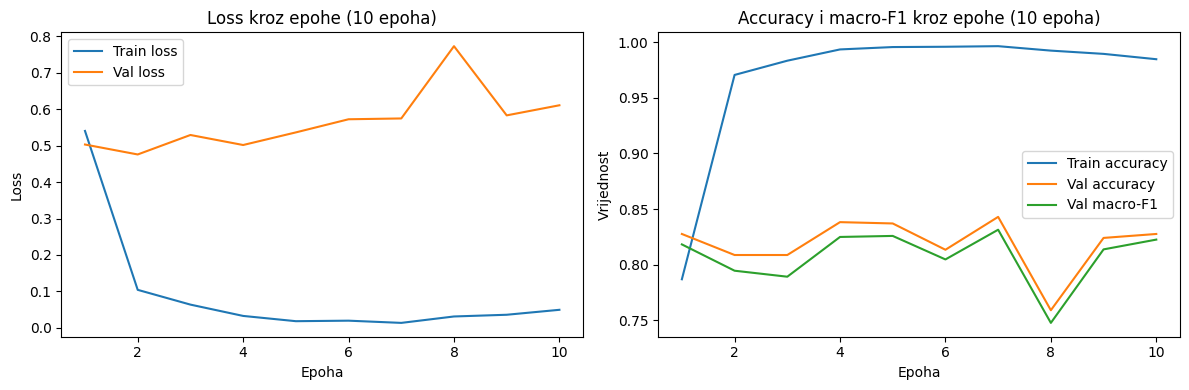

In [11]:
import matplotlib.pyplot as plt
import os

os.makedirs('results/10_produzeni_trening', exist_ok=True)

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe (10 epoha)')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].plot(epochs, history['val_f1'], label='Val macro-F1')
axes[1].set_xlabel('Epoha'); axes[1].set_ylabel('Vrijednost')
axes[1].set_title('Accuracy i macro-F1 kroz epohe (10 epoha)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/10_produzeni_trening/grafik_metrika_10ep.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = 'epoha'
history_df.to_csv('results/10_produzeni_trening/istorija_metrika_10ep.csv')
print(history_df)

       train_loss  train_acc  val_loss   val_acc    val_f1
epoha                                                     
1        0.540219   0.786951  0.502971  0.827627  0.818267
2        0.104274   0.970439  0.475693  0.808737  0.794632
3        0.063762   0.983222  0.529132  0.808737  0.789259
4        0.032726   0.993342  0.501622  0.838253  0.824949
5        0.018284   0.995473  0.536236  0.837072  0.825875
6        0.019689   0.995739  0.572271  0.813459  0.804766
7        0.013624   0.996272  0.574500  0.842975  0.831450
8        0.031218   0.992277  0.772805  0.759150  0.747785
9        0.035920   0.989348  0.582935  0.824085  0.813792
10       0.049514   0.984554  0.610660  0.827627  0.822573


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns

def evaluate_on_test(y_true, y_pred, model_name, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} — TEST rezultati ===")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predikcija'); plt.ylabel('Stvarna klasa')
    plt.title(f'{model_name} — matrica konfuzije (TEST)')
    plt.savefig('results/10_produzeni_trening/matrica_konfuzije_test_10ep.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1}

=== Transfer learning (ResNet18, 10 epoha) — TEST rezultati ===
Accuracy: 0.8566   Macro-F1: 0.8261

              precision    recall  f1-score   support

         tom       0.84      0.95      0.89       289
       jerry       0.85      0.87      0.86       194
        both       0.93      0.51      0.66       131
     neither       0.86      0.93      0.89       230

    accuracy                           0.86       844
   macro avg       0.87      0.81      0.83       844
weighted avg       0.86      0.86      0.85       844



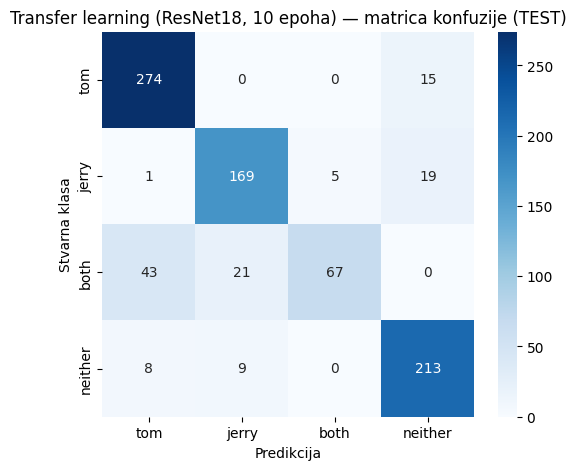

In [14]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

y_true_ime = [idx_to_class[i] for i in y_true]
y_pred_ime = [idx_to_class[i] for i in y_pred]
class_names = ['tom', 'jerry', 'both', 'neither']

rezultat_transfer_10ep = evaluate_on_test(y_true_ime, y_pred_ime, "Transfer learning (ResNet18, 10 epoha)", class_names)

## Zaključak — poređenje 5 vs 10 epoha

- **5 epoha (originalno, 04):** test macro-F1 = 0.79
- **10 epoha (ovaj notebook):** test macro-F1 = 0.8261, accuracy = 0.8566 — vidljiv boljitak
- **Najbolja epoha je bila 7, ne 10** — checkpointing po val macro-F1 (0.8314) je uhvatio tu epohu i vratio te težine u model. To je ključni razlog zašto je produženi trening pomogao: original (04) je birao najbolju epohu samo među prvih 5, dok je ovdje mreža dobila priliku da dosegne bolju tačku (epoha 7) koja u kraćem treningu uopšte nije bila u izboru.
- **Poslije epohe 7 val macro-F1 više ne napreduje** — oštro pada u epohi 8 (0.7478), pa se oporavlja na 0.8138 i 0.8226, ali nijednom ne prelazi 0.8314. Trening duži od 10 epoha vjerovatno ne bi pomogao, model je već prošao svoju najbolju tačku.
- **Overfitting je prisutan tokom cijelog treninga** — train accuracy >99% već od epohe 2 i train loss skoro 0, dok val loss od epohe 2 uporno raste (0.4757 → 0.6107). Poboljšanje na val/test skupu zato ne dolazi od toga što model bolje generalizuje, nego od toga što je checkpointing, imajući više kandidata (10 umjesto 5), uspio da izabere jednu posebno dobru epohu prije nego što je overfitting počeo ozbiljnije da šteti.
- **Najslabija klasa je "both"** (recall 0.51) — od 131 slike sa oba lika, 43 su predviđene kao "tom", a 21 kao "jerry". Model prepozna jednog lika i tu stane, što je očekivano za single-label formulaciju u kojoj je "both" ujedno i najmanje zastupljena klasa.
- **Napomena o ponovljivosti:** seed nije fiksiran, pa se rezultati između pokretanja razlikuju — u ranijem pokretanju najbolja je bila epoha 8 (val macro-F1 0.8513), u ovom epoha 7 (0.8314). Smjer zaključka — 10 epoha daje mjerljivo bolji rezultat od 5 — ostaje isti, ali pojedinačne brojke treba čitati kao okvirne, ne kao tačne na 4 decimale.

In [17]:
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/resnet18_transfer_10ep.pt')
size_mb = os.path.getsize('models/resnet18_transfer_10ep.pt') / (1024*1024)
print(f"resnet18_transfer_10ep.pt: {size_mb:.1f} MB")

resnet18_transfer_10ep.pt: 42.7 MB


In [18]:
!git add models/resnet18_transfer_10ep.pt results/10_produzeni_trening/
!git commit -m "Dodaj produzeni trening ResNet18 (10 epoha) - rezultati, grafici i model"
!git push

[main 6f16cf4] Dodaj produzeni trening ResNet18 (10 epoha) - rezultati, grafici i model
 4 files changed, 11 insertions(+)
 create mode 100644 models/resnet18_transfer_10ep.pt
 create mode 100644 results/10_produzeni_trening/grafik_metrika_10ep.png
 create mode 100644 results/10_produzeni_trening/istorija_metrika_10ep.csv
 create mode 100644 results/10_produzeni_trening/matrica_konfuzije_test_10ep.png
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (9/9), 39.76 MiB | 11.89 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification.git
   9c5d3d7..6f16cf4  main -> main
